In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
#loading Dataset

df=pd.read_csv("C:\\Users\\TANVI SHELAR\\Downloads\\bitcoinheistransomwareaddressdataset.zip")
df.head()

,address,year,day,length,weight,count,looped,neighbors,income,label
0,111K8kZAEnJg245r2cM6y9zgJGHZtJPy6,2017,11,18,0.008333,1,0,2,100050000.0,princetonCerber
1,1123pJv8jzeFQaCV4w644pzQJzVWay2zcA,2016,132,44,0.000244,1,0,1,100000000.0,princetonLocky
2,112536im7hy6wtKbpH1qYDWtTyMRAcA2p7,2016,246,0,1.000000,1,0,2,200000000.0,princetonCerber
3,1126eDRw2wqSkWosjTCre8cjjQW8sSeWH7,2016,322,72,0.003906,1,0,2,71200000.0,princetonCerber
4,1129TSjKtx65E35GiUo4AYVeyo48twbrGX,2016,238,144,0.072848,456,0,1,200000000.0,princetonLocky


In [3]:
#To get the columns and their datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2916697 entries, 0 to 2916696
Data columns (total 10 columns):
 #   Column     Dtype  
---  ------     -----  
 0   address    object 
 1   year       int64  
 2   day        int64  
 3   length     int64  
 4   weight     float64
 5   count      int64  
 6   looped     int64  
 7   neighbors  int64  
 8   income     float64
 9   label      object 
dtypes: float64(2), int64(6), object(2)
memory usage: 222.5+ MB


In [4]:
#To check null values
numeric_cols = ['year','day','length','weight','count','looped','neighbors','income']
df[numeric_cols].isna().sum()

year         0
day          0
length       0
weight       0
count        0
looped       0
neighbors    0
income       0
dtype: int64

In [5]:
#dropping irrevelant columns

df = df.drop(columns=['address']) 

#notes: the address column is just an ID, not useful for prediction.

In [6]:
#Remove duplicates

df = df.drop_duplicates()

In [7]:
#To check unique values in label colums

df["label"].unique()

array(['princetonCerber', 'princetonLocky', 'montrealCryptoLocker',
       'montrealCryptXXX', 'paduaCryptoWall', 'montrealWannaCry',
       'montrealDMALockerv3', 'montrealCryptoTorLocker2015',
       'montrealSamSam', 'montrealFlyper', 'montrealNoobCrypt',
       'montrealDMALocker', 'montrealGlobe', 'montrealEDA2',
       'paduaKeRanger', 'montrealVenusLocker', 'montrealXTPLocker',
       'paduaJigsaw', 'montrealGlobev3', 'montrealJigSaw',
       'montrealXLockerv5.0', 'montrealXLocker', 'montrealRazy',
       'montrealCryptConsole', 'montrealGlobeImposter', 'montrealSam',
       'montrealComradeCircle', 'montrealAPT', 'white'], dtype=object)

In [8]:
#Encode labels into 0 (normal) and 1 (ransomware)

#Notes: We know 'white' = normal(0), everything else = ransomware (1).

#Encode ransomware vs normal 
df['label'] = df['label'].apply(lambda x: 0 if x == 'white' else 1)

In [9]:
#verifying encoding worked
df['label'].value_counts()

label
0    2826218
1      39637
Name: count, dtype: int64

In [10]:
df.describe()

,year,day,length,weight,count,looped,neighbors,income,label
count,2.865855e+06,2.865855e+06,2.865855e+06,2.865855e+06,2.865855e+06,2.865855e+06,2.865855e+06,2.865855e+06,2.865855e+06
mean,2.014494e+03,1.817096e+02,4.570654e+01,5.460509e-01,7.322652e+02,2.419946e+02,2.220100e+00,4.527565e+09,1.383078e-02
std,2.251988e+00,1.039192e+02,5.917819e+01,3.706292e+00,1.699582e+03,9.722659e+02,1.807656e+01,1.641171e+11,1.167882e-01
min,2.011000e+03,1.000000e+00,0.000000e+00,3.606469e-94,1.000000e+00,0.000000e+00,1.000000e+00,3.000000e+07,0.000000e+00
25%,2.013000e+03,9.200000e+01,2.000000e+00,2.118283e-02,1.000000e+00,0.000000e+00,1.000000e+00,7.410860e+07,0.000000e+00
50%,2.015000e+03,1.820000e+02,1.000000e+01,2.500000e-01,1.000000e+00,0.000000e+00,2.000000e+00,2.000000e+08,0.000000e+00
75%,2.016000e+03,2.710000e+02,1.140000e+02,8.696959e-01,6.100000e+01,0.000000e+00,2.000000e+00,9.999900e+08,0.000000e+00
max,2.018000e+03,3.650000e+02,1.440000e+02,1.943749e+03,1.449700e+04,1.449600e+04,1.292000e+04,4.996440e+13,1.000000e+00


In [11]:
df.corr()

,year,day,length,weight,count,looped,neighbors,income,label
year,1.000000,-0.042593,0.159421,0.011571,0.285322,0.112504,-0.001409,-0.020889,0.018082
day,-0.042593,1.000000,0.010018,0.000948,-0.003919,0.001210,0.000049,0.002643,-0.007233
length,0.159421,0.010018,1.000000,0.000318,0.702464,0.410766,0.031162,0.000227,-0.004962
weight,0.011571,0.000948,0.000318,1.000000,0.022476,0.061871,0.692033,0.069775,0.002684
count,0.285322,-0.003919,0.702464,0.022476,1.000000,0.559570,0.025225,-0.003786,-0.007824
looped,0.112504,0.001210,0.410766,0.061871,0.559570,1.000000,0.052789,0.002479,-0.017380
neighbors,-0.001409,0.000049,0.031162,0.692033,0.025225,0.052789,1.000000,0.138957,-0.000810
income,-0.020889,0.002643,0.000227,0.069775,-0.003786,0.002479,0.138957,1.000000,-0.002681
label,0.018082,-0.007233,-0.004962,0.002684,-0.007824,-0.017380,-0.000810,-0.002681,1.000000


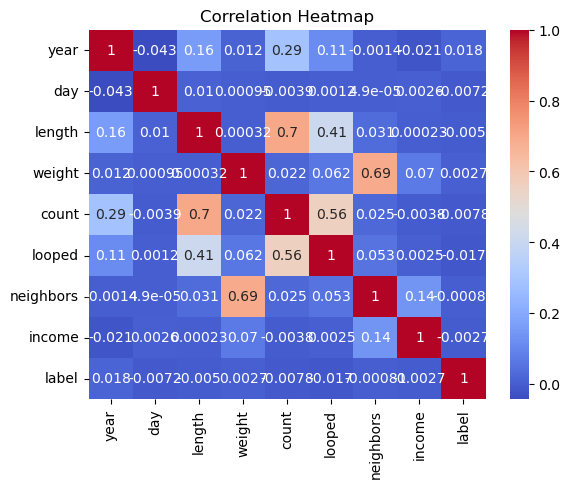

In [12]:
# Correlation heatmap
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Notes : This heatmap shows how strongly each feature is correlated with others.The length and count columns have a strong positive correlation (0.7),
while weight and neighbors are also moderately correlated (0.69).Most other features show weak or no correlation with income or label, 
indicating limited linear relationships.**

**Feature Impact on Income (Top Correlation Display)**

In [13]:
corr_income = df.corr(numeric_only=True)['income'].sort_values(ascending=False)
# Select top 6 and lowest 6 correlations
top_corr = corr_income.head(6)
low_corr = corr_income.tail(6)

C:\Users\TANVI SHELAR\AppData\Local\Temp\ipykernel_9732\823148025.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette="Greens_r")


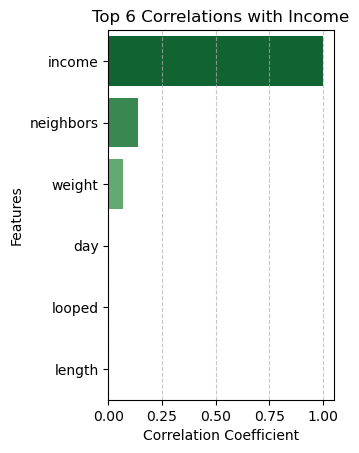

In [14]:
# --- Top Correlations ---
plt.subplot(1, 2, 1)
sns.barplot(x=top_corr.values, y=top_corr.index, palette="Greens_r")
plt.title("Top 6 Correlations with Income")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)

**Notes:This bar chart displays the top 6 features most correlated with income.
neighbors and weight have the highest positive correlations, though still weak overall.
This suggests that as the number of neighbors or transaction weight increases, income tends to rise slightly.**

C:\Users\TANVI SHELAR\AppData\Local\Temp\ipykernel_9732\1309620864.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=low_corr.values, y=low_corr.index, palette="Reds")


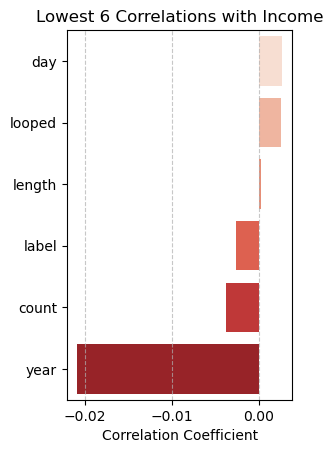

In [15]:
# --- Lowest Correlations ---
plt.subplot(1, 2, 2)
sns.barplot(x=low_corr.values, y=low_corr.index, palette="Reds")
plt.title("Lowest 6 Correlations with Income")
plt.xlabel("Correlation Coefficient")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.7)

**Notes: This chart highlights the features with the lowest (negative) correlations to income.
year has the most negative correlation, implying that income tends to reduce slightly in later years.
Other features like looped, length, and label show almost no linear relationship with income.**

**Overall Transaction Statistics**

In [100]:
# Select numeric columns
numeric_cols = ['length', 'weight', 'count', 'looped', 'neighbors', 'income']

# Overall transaction statistics
overall_stats = df[numeric_cols].agg(['mean', 'sum', 'std']).T  # Transpose for readability
overall_stats.reset_index(inplace=True)
overall_stats.columns = ['Feature', 'Mean', 'Total', 'Std_Dev']

print("📊 Overall Transaction Statistics:\n")
display(overall_stats)

📊 Overall Transaction Statistics:



,Feature,Mean,Total,Std_Dev
0,length,45.706540,1.309883e+08,59.178194
1,weight,0.326726,9.363485e+05,0.357076
2,count,2.669753,7.651125e+06,2.960629
3,looped,4.518444,1.294921e+07,14.885509
4,neighbors,1.017521,2.916067e+06,0.315882
5,income,19.543199,5.600798e+07,1.791540


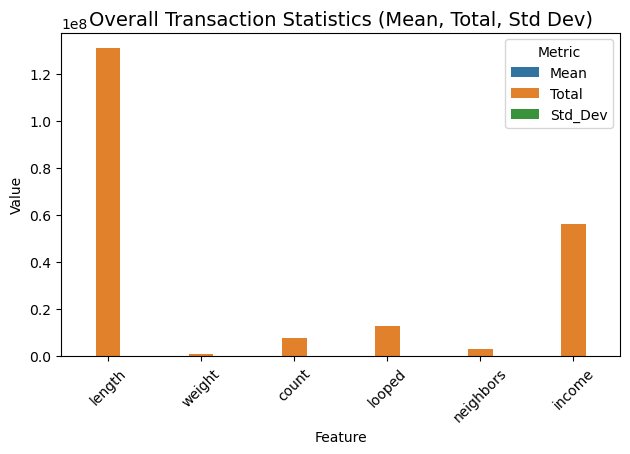

In [101]:
# Melt for multiple metrics plotting
overall_melted = overall_stats.melt(id_vars='Feature', var_name='Metric', value_name='Value')

sns.barplot(x='Feature', y='Value', hue='Metric', data=overall_melted)
plt.title('Overall Transaction Statistics (Mean, Total, Std Dev)', fontsize=14)
plt.xlabel('Feature')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Notes: This chart compares the mean, total, and standard deviation for each numeric feature.
length and income dominate in total value, meaning they contribute the most to overall transaction volume.
The large difference between total and mean indicates high variation in transaction scales.**

**Ransomware vs Normal Trend Over Time**

In [17]:
#How do the number and percentage of ransomware vs normal  transactions change by year?

#Number of ransomware vs normal transactions change by year
yearly_counts = df.groupby(['year','label']).size().unstack(fill_value=0)

#Percentage of ransomware vs normal transactions change by year
yearly_percent = yearly_counts.div(yearly_counts.sum(axis=1),axis=0)*100

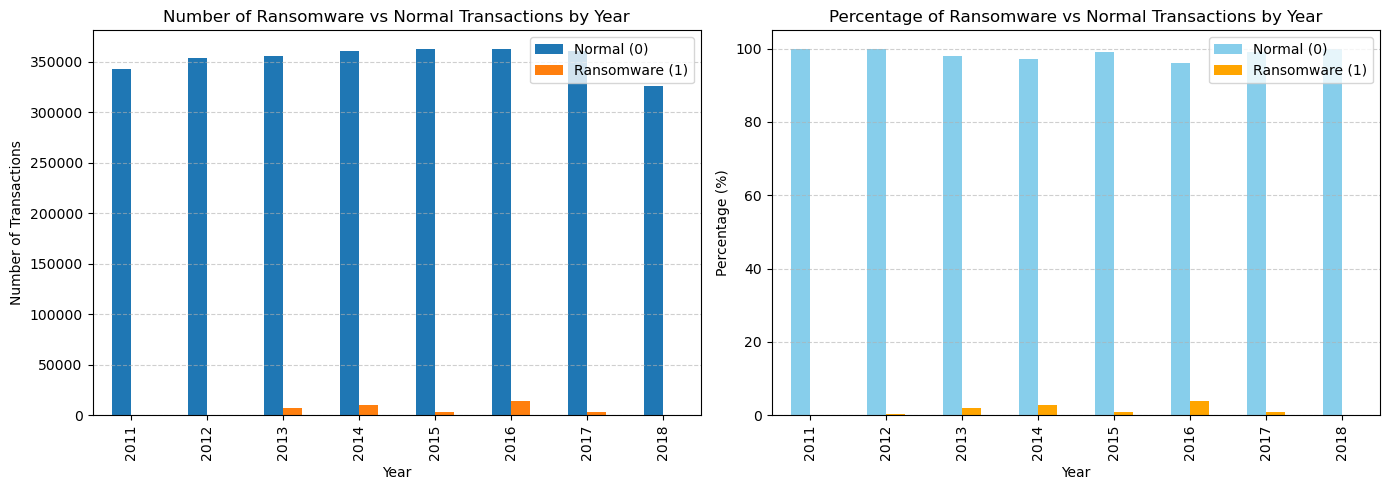

In [18]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# --- Left: Number of transactions ---
yearly_counts.plot(kind='bar', ax=axes[0])
axes[0].set_title('Number of Ransomware vs Normal Transactions by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Transactions')
axes[0].legend(['Normal (0)', 'Ransomware (1)'])
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# --- Right: Percentage of ransomware vs normal transactions ---
yearly_percent.plot(kind='bar', ax=axes[1], color=['skyblue','orange'])
axes[1].set_title('Percentage of Ransomware vs Normal Transactions by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(['Normal (0)', 'Ransomware (1)'])
axes[1].grid(axis='y', linestyle='--',alpha=0.6)

plt.tight_layout()
plt.show()

**Notes: The left chart shows total counts per year, while the right shows percentages.
Normal transactions vastly outnumber ransomware ones every year.
Ransomware activity peaks slightly around 2015–2016, then declines, showing temporal variation in attack activity..**

**Outliers and High-Value Transactions**

In [19]:
#Which addresses have unusually high transaction counts or income, and are they mostly ransomware ?

df.sort_values('income',ascending=False).head(20)
df[df['count']>df['count'].quantile(0.99)]

,year,day,length,weight,count,looped,neighbors,income,label
31,2016,52,144,0.099878,8120,0,1,5.005795e+07,1
70,2017,139,144,1.031474,8973,0,2,6.447900e+07,1
73,2017,137,144,1.500020,9866,0,2,7.047766e+07,1
173,2016,56,144,0.078125,9543,0,1,5.000000e+07,1
498,2017,111,144,0.456645,8276,0,2,8.000000e+07,1
...,...,...,...,...,...,...,...,...,...
2916654,2018,330,144,0.191248,8247,8247,1,1.999500e+08,0
2916667,2018,330,144,0.754501,8247,8247,5,2.610370e+09,0
2916677,2018,330,144,0.216679,8162,0,1,3.339973e+09,0
2916680,2018,330,144,0.717451,8247,8247,3,1.419406e+09,0


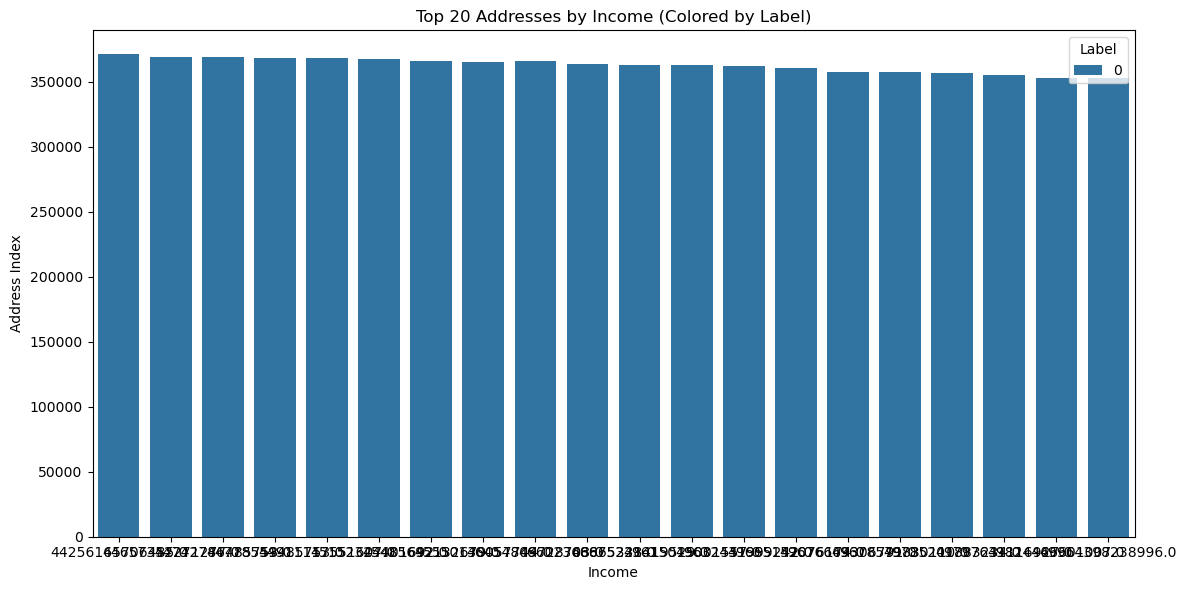

In [22]:
top_income = df.sort_values('income', ascending=False).head(20)

plt.figure(figsize=(12,6))
sns.barplot(x='income', y=top_income.index, data=top_income, hue='label')
plt.title('Top 20 Addresses by Income (Colored by Label)')
plt.xlabel('Income')
plt.ylabel('Address Index')
plt.legend(title='Label')
plt.tight_layout()
plt.show()

**Notes: This bar chart shows the top 20 Bitcoin addresses ranked by income.
All high-income addresses are labeled as Normal (0), suggesting that the most profitable addresses are not associated with ransomware.
This indicates ransomware wallets tend to handle smaller transaction volumes.**

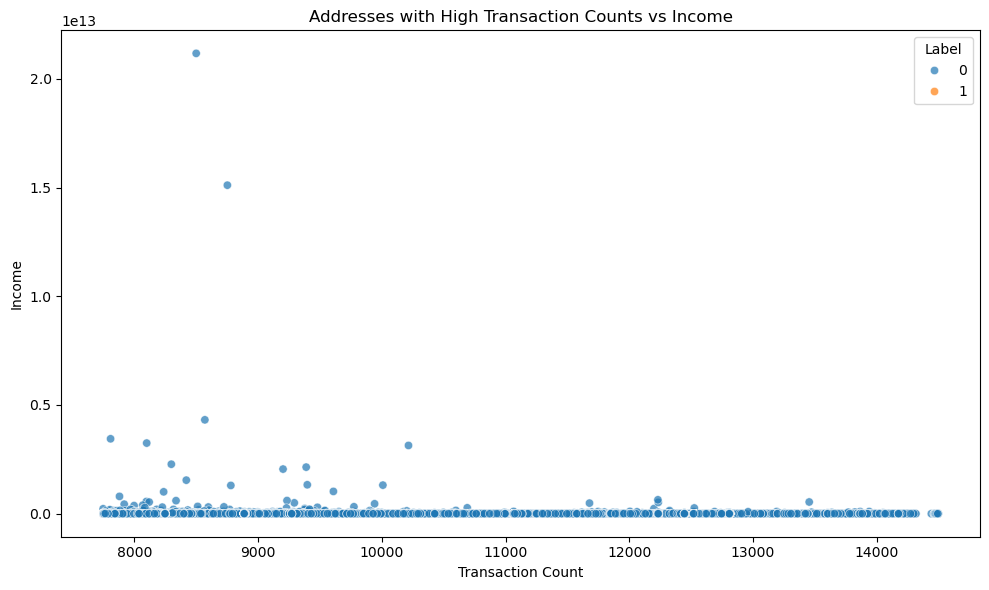

In [23]:
high_count = df[df['count'] > df['count'].quantile(0.99)]

plt.figure(figsize=(10,6))
sns.scatterplot(data=high_count, x='count', y='income', hue='label', alpha=0.7)
plt.title('Addresses with High Transaction Counts vs Income')
plt.xlabel('Transaction Count')
plt.ylabel('Income')
plt.legend(title='Label')
plt.tight_layout()
plt.show()

**Notes: This scatter plot shows the relationship between transaction count and income.
A few addresses have extremely high incomes, but most cluster near the bottom, indicating skewed income distribution.
Ransomware-labeled addresses (orange) are fewer and have comparatively lower income levels.**

**Income Distribution Over Time**

In [24]:
#How average and total income changes yearly, separated by label.

total_income = df.groupby(['year', 'label'])['income'].sum().unstack()
avg_income = df.groupby(['year', 'label'])['income'].mean().unstack()

print(total_income)
print(avg_income)

label             0             1
year                             
2011   4.490316e+15  1.130875e+10
2012   3.690571e+15  5.645224e+11
2013   1.435924e+15  1.834023e+13
2014   5.764141e+14  9.028172e+12
2015   7.037031e+14  1.049070e+12
2016   7.872517e+14  2.785193e+12
2017   7.332789e+14  4.067899e+11
2018   5.257021e+14  3.440475e+08
label             0             1
year                             
2011   1.310199e+10  1.739807e+08
2012   1.042991e+10  7.906476e+08
2013   4.030414e+09  2.488161e+09
2014   1.595941e+09  8.803678e+08
2015   1.937887e+09  2.894783e+08
2016   2.172112e+09  1.953561e+08
2017   2.033519e+09  1.215024e+08
2018   1.612360e+09  1.146825e+08


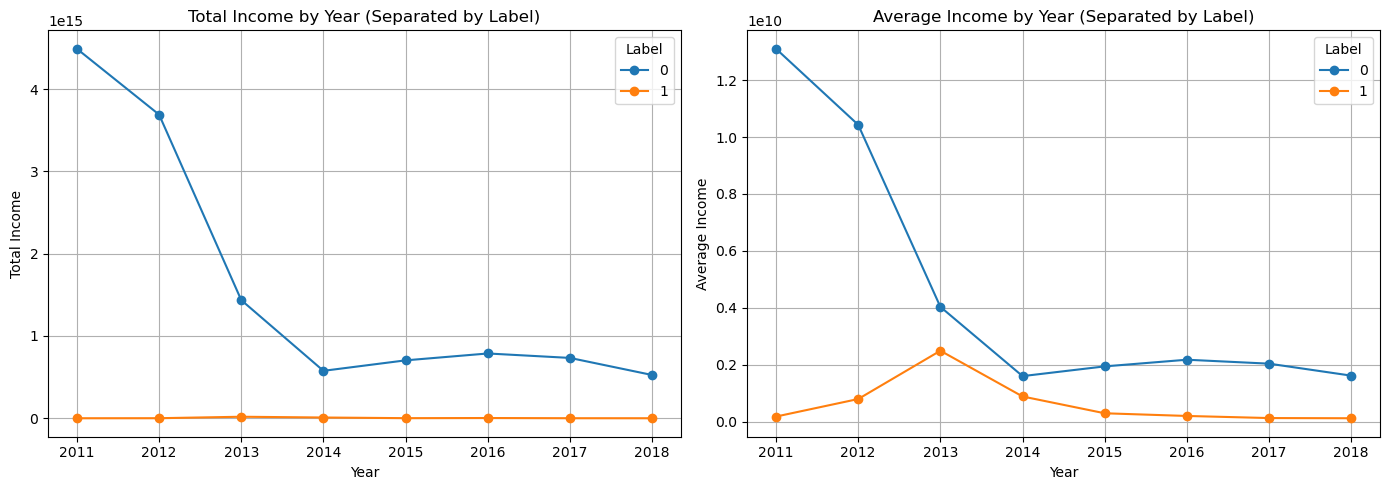

In [25]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# --- Total Income ---
total_income.plot(kind='line', marker='o', ax=axes[0])
axes[0].set_title('Total Income by Year (Separated by Label)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Income')
axes[0].grid(True)
axes[0].legend(title='Label')

# --- Average Income ---
avg_income.plot(kind='line', marker='o', ax=axes[1])
axes[1].set_title('Average Income by Year (Separated by Label)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Income')
axes[1].grid(True)
axes[1].legend(title='Label')

# Adjust layout
plt.tight_layout()
plt.show()

**Notes: These line plots show yearly income trends for ransomware and normal transactions.
Normal transactions dominate both total and average income.
Ransomware income peaks around 2013–2014 but remains significantly lower overall, showing limited financial scale.**

**High Income vs Low-Income Comparison**

In [26]:
median_income = df['income'].median()
high_income = df[df['income'] > median_income]
low_income = df[df['income'] <= median_income]

compare = pd.DataFrame({
    'High Income Avg': high_income[['length','weight','count','neighbors']].mean(),
    'Low Income Avg': low_income[['length','weight','count','neighbors']].mean()
})
print(compare)

           High Income Avg  Low Income Avg
length           44.960095       46.439878
weight            0.678749        0.415683
count           662.165775      801.133741
neighbors         2.761180        1.688521


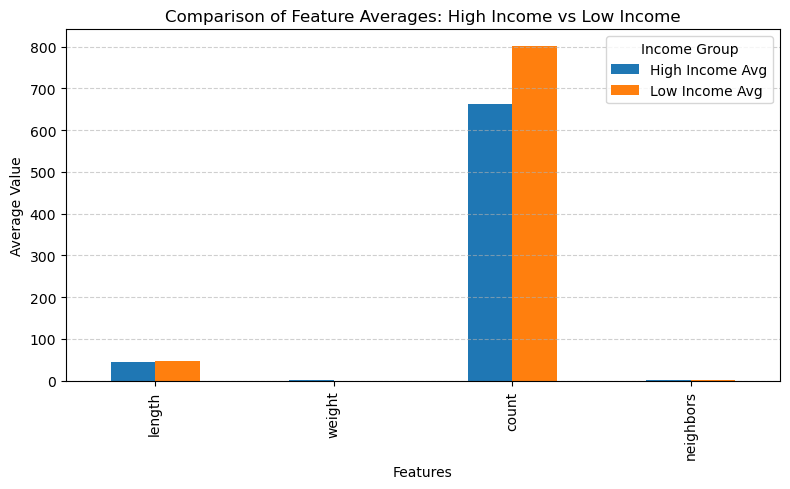

In [27]:
# Plot comparison
compare.plot(kind='bar', figsize=(8,5))
plt.title('Comparison of Feature Averages: High Income vs Low Income')
plt.xlabel('Features')
plt.ylabel('Average Value')
plt.legend(title='Income Group')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Notes: This chart compares key feature averages between high-income and low-income addresses.
High-income groups tend to have slightly higher count and length values, indicating that frequent or longer transactions lead to higher earnings.**

**Ransomware vs Normal - Detailed Statistical Comparisson**

In [28]:
ransom = df[df['label'] == 1]
normal = df[df['label'] == 0]

compare_label = pd.DataFrame({
    'Ransomware Avg': ransom[['length','weight','count','neighbors','income']].mean(),
    'Normal Avg': normal[['length','weight','count','neighbors','income']].mean()
})
print(compare_label)

           Ransomware Avg    Normal Avg
length       4.322683e+01  4.574132e+01
weight       6.300511e-01  5.448728e-01
count        6.199808e+02  7.338400e+02
neighbors    2.096526e+00  2.221833e+00
income       8.120098e+08  4.579675e+09


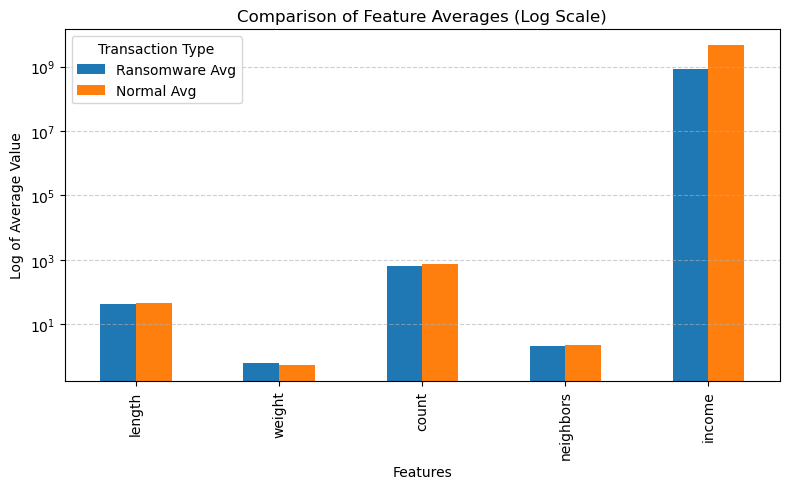

In [29]:
compare_label.plot(kind='bar', figsize=(8,5), logy=True)
plt.title('Comparison of Feature Averages (Log Scale)')
plt.xlabel('Features')
plt.ylabel('Log of Average Value')
plt.legend(title='Transaction Type')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Notes: Using a log scale, this chart compares feature averages across transaction types.
Normal transactions consistently have higher averages in features like income and count.
This suggests ransomware wallets have lower overall transaction volume and income.**

**Looped Transaction Behaviour**

In [30]:
looped_group = df.groupby('looped')[['count','income','neighbors']].mean().sort_index().head(50)
#print(looped_group)

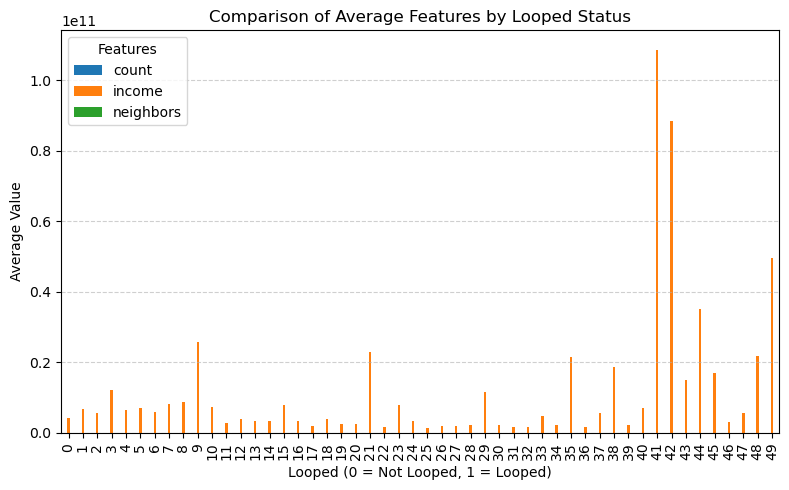

In [31]:
looped_group.plot(kind='bar', figsize=(8,5))
plt.title('Comparison of Average Features by Looped Status')
plt.xlabel('Looped (0 = Not Looped, 1 = Looped)')
plt.ylabel('Average Value')
plt.legend(title='Features')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Notes:This chart compares the average values of count, income, and neighbors for different looped transaction statuses (0 = Not Looped, 1 = Looped).
It shows that while transaction counts and neighbors remain relatively stable, income varies significantly across looped categories — especially in a few looped groups, which show large spikes.
This indicates that certain looped transaction patterns are associated with very high-income addresses, possibly due to repeated fund movements.**

**Neighbor Effect on Income**

In [32]:
neighbor_bins = pd.cut(df['neighbors'], bins=5)
avg_income_by_neighbors = df.groupby(neighbor_bins)['income'].mean()
print(avg_income_by_neighbors)

neighbors
(-11.919, 2584.8]     4.504655e+09
(2584.8, 5168.6]      1.135133e+13
(5168.6, 7752.4]      3.097054e+12
(7752.4, 10336.2]              NaN
(10336.2, 12920.0]    8.594112e+12
Name: income, dtype: float64


C:\Users\TANVI SHELAR\AppData\Local\Temp\ipykernel_9732\1152190145.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_income_by_neighbors = df.groupby(neighbor_bins)['income'].mean()


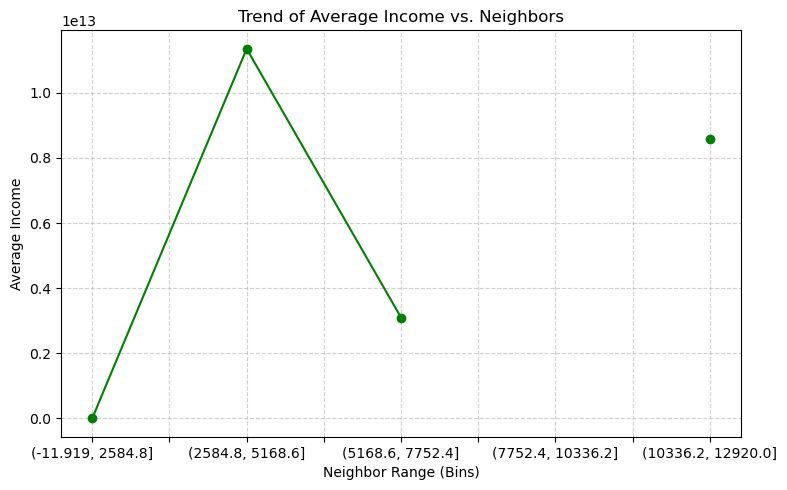

In [33]:
avg_income_by_neighbors.plot(kind='line', marker='o', figsize=(8,5), color='green')

plt.title('Trend of Average Income vs. Neighbors')
plt.xlabel('Neighbor Range (Bins)')
plt.ylabel('Average Income')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


**Notes: This line plot shows how average income changes with different ranges (bins) of the neighbors feature.
Income peaks in the middle range of neighbors (≈2500–5000), suggesting that addresses with moderate neighbor connections tend to have the highest incomes.
At very low or very high neighbor counts, average income drops, implying that extreme connectivity may not necessarily result in higher earnings.**

**Skewness & Transformations**

In [34]:
skews= df[numeric_cols].skew()
print(skews)

year          -0.007805
day            0.005984
length         0.901424
weight       240.968911
count          2.902175
looped         5.480474
neighbors    291.030390
income       226.391022
dtype: float64


In [35]:
# Apply transformations
df['weight_log'] = np.log1p(df['weight'])
df['count_log'] = np.log1p(df['count'])
df['neighbors_log'] = np.log1p(df['neighbors'])
df['income_log'] = np.log1p(df['income'])
df['looped_sqrt'] = np.sqrt(df['looped'])

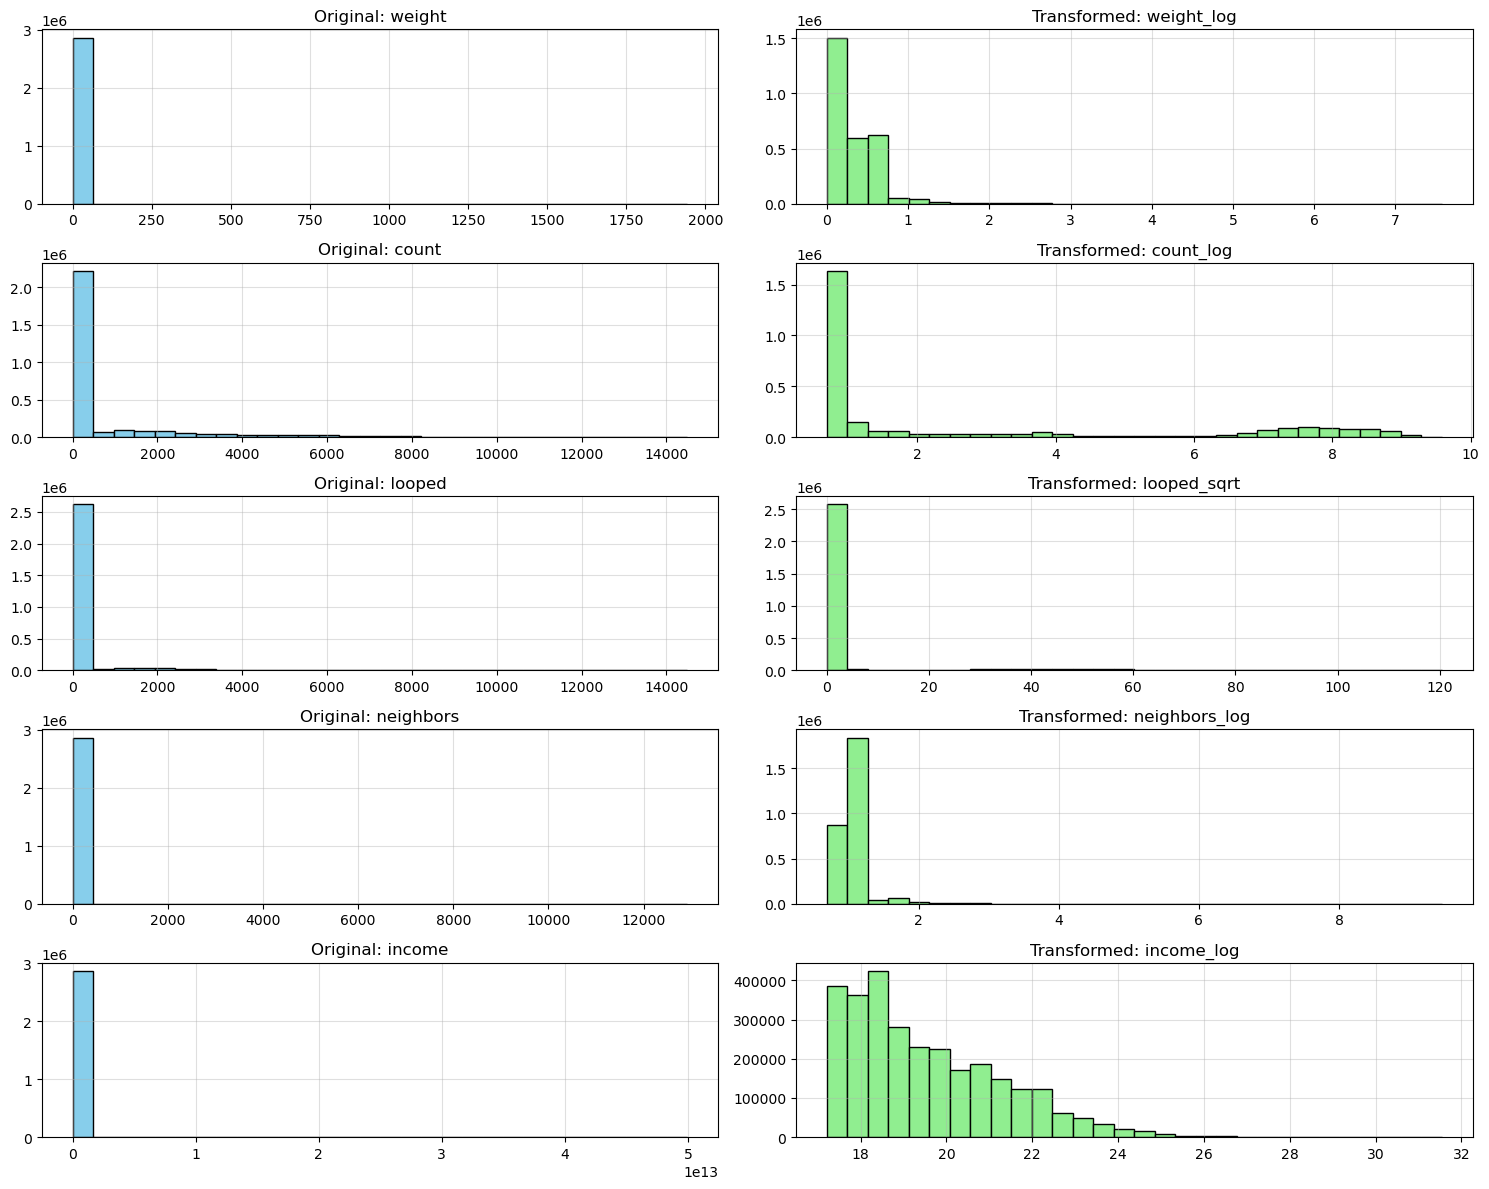

In [36]:
#Plot before vs after transformation

skewed_cols = ['weight', 'count', 'looped', 'neighbors', 'income']
transformed_cols = ['weight_log', 'count_log', 'looped_sqrt', 'neighbors_log', 'income_log']

plt.figure(figsize=(15, 12))

for i, (orig, trans) in enumerate(zip(skewed_cols, transformed_cols)):
    plt.subplot(5, 2, 2*i + 1)
    plt.hist(df[orig], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Original: {orig}')
    plt.grid(alpha=0.4)

    plt.subplot(5, 2, 2*i + 2)
    plt.hist(df[trans], bins=30, color='lightgreen', edgecolor='black')
    plt.title(f'Transformed: {trans}')
    plt.grid(alpha=0.4)

plt.tight_layout()
plt.show()


In [37]:
#Check new skewness values

new_skew = df[['weight_log', 'count_log', 'looped_sqrt', 'neighbors_log', 'income_log']].skew()
print("New Skewness After Transformation:\n", new_skew)

New Skewness After Transformation:
 weight_log       2.384232
count_log        1.107176
looped_sqrt      3.563755
neighbors_log    4.548961
income_log       0.911915
dtype: float64


In [38]:
#Next Steps to Fix the Remaining Skewness
#Using Yeo–Johnson Transformation
from sklearn.preprocessing import PowerTransformer

# Selected the skewed columns that still need fixing
cols_to_fix = ['weight', 'neighbors', 'looped']

pt = PowerTransformer(method='yeo-johnson')
df[cols_to_fix] = pt.fit_transform(df[cols_to_fix])

# Checked new skewness
print("Skewness after Yeo-Johnson transformation:\n", df[cols_to_fix].skew())

Skewness after Yeo-Johnson transformation:
 weight       0.241237
neighbors   -0.060766
looped       2.154310
dtype: float64


In [39]:
#Scaling  the remaining continuous features
from sklearn.preprocessing import StandardScaler

scaled_cols = ['weight', 'count', 'neighbors', 'income']  # only continuous variables
scaler = StandardScaler()
df[scaled_cols] = scaler.fit_transform(df[scaled_cols])

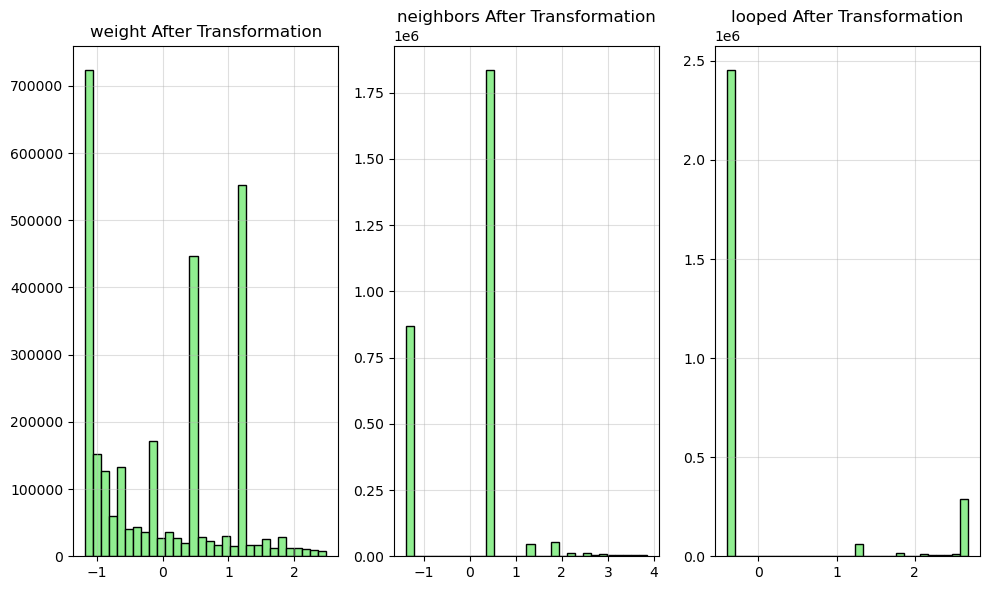

In [40]:
#Verifying final distribution visually
final_cols = ['weight', 'neighbors', 'looped']
plt.figure(figsize=(10,6))

for i, col in enumerate(final_cols):
    plt.subplot(1, 3, i+1)
    plt.hist(df[col], bins=30, color='lightgreen', edgecolor='black')
    plt.title(f'{col} After Transformation')
    plt.grid(alpha=0.4)

plt.tight_layout()
plt.show()

In [41]:
#Replace each original columns with its tranformed versions

df['weight'] = df['weight_log']
df['count'] = df['count_log']
df['neighbors'] = df['neighbors_log']
df['income'] = df['income_log']
df['looped'] = df['looped_sqrt']

In [42]:
#Droping  the temporary transformed columns
df.drop(columns=['weight_log', 'count_log', 'neighbors_log', 'income_log', 'looped_sqrt'], inplace=True)

In [43]:
#Verifying to confirm replacement worked
df.head()

,year,day,length,weight,count,looped,neighbors,income,label
0,2017,11,18,0.008299,0.693147,0.0,1.098612,18.421181,1
1,2016,132,44,0.000244,0.693147,0.0,0.693147,18.420681,1
2,2016,246,0,0.693147,0.693147,0.0,1.098612,19.113828,1
3,2016,322,72,0.003899,0.693147,0.0,1.098612,18.081003,1
4,2016,238,144,0.070317,6.124683,0.0,0.693147,19.113828,1


**Modeling Setup**

In [41]:
!pip install -q xgboost imbalanced-learn

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [45]:
le=LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

#Choose features (use income depending on skewness handling)
features = ['length','weight','count','looped','neighbors','income']
X = df[features]
y = df['label_encoded']

#Stratified split to keep class ration
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

**MODELS WITHOUT SMOTE**

**Logistic Regression(Without SMOTE)**

In [65]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [79]:
y_pred_log = log_model.predict(X_test)

print("Logistic Regression (No SMOTE)")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression (No SMOTE)
Accuracy: 0.9861699213672709
Recall: 0.0
Confusion Matrix:
 [[565244      0]
 [  7927      0]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    565244
           1       0.00      0.00      0.00      7927

    accuracy                           0.99    573171
   macro avg       0.49      0.50      0.50    573171
weighted avg       0.97      0.99      0.98    573171



C:\Users\TANVI SHELAR\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\TANVI SHELAR\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\TANVI SHELAR\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Random Forest (Without SMOTE)**

In [47]:
rf_model=RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42,n_jobs=-1)

In [48]:
rf_model.fit(X_train,y_train)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

In [81]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest (No SMOTE)")
print("Accuracy:", accuracy_score(y_test,y_pred_rf))
print("Recall:", recall_score(y_test,y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))

Random Forest (No SMOTE)
Accuracy: 0.9861716660473052
Recall: 0.00012615112905260502
Confusion Matrix:
 [[565244      0]
 [  7926      1]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    565244
           1       1.00      0.00      0.00      7927

    accuracy                           0.99    573171
   macro avg       0.99      0.50      0.50    573171
weighted avg       0.99      0.99      0.98    573171



**XGBoost (Without SMOTE)**

In [52]:
xgb_model=XGBClassifier(eval_metric='logloss',random_state=42)

In [53]:
xgb_model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [82]:
y_pred_xgb=xgb_model.predict(X_test)

print("XGBoost (No SMOTE)")
print("Accuracy:", accuracy_score(y_test,y_pred_xgb))
print("Recall:", recall_score(y_test,y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred_xgb))
print(classification_report(y_test,y_pred_xgb))

XGBoost (No SMOTE)
Accuracy: 0.9861594532870644
Recall: 0.0022707203229468905
Confusion Matrix:
 [[565220     24]
 [  7909     18]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    565244
           1       0.43      0.00      0.00      7927

    accuracy                           0.99    573171
   macro avg       0.71      0.50      0.50    573171
weighted avg       0.98      0.99      0.98    573171



**Handling Class Imbalance(Applying SMOTE)**

In [55]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X,y)
print('Before:',y.value_counts().to_dict())
print('After:',y_res.value_counts().to_dict())

#Split balanced data
X_train_s,X_test_s,y_train_s,y_test_s = train_test_split(X_res,y_res,test_size=0.2,random_state=42)

Before: {0: 2826218, 1: 39637}
After: {1: 2826218, 0: 2826218}


**Logistic Regression (With SMOTE)**

In [67]:
log_model_sm = LogisticRegression(max_iter=1000, random_state=42)
log_model_sm.fit(X_train_s, y_train_s)

LogisticRegression(max_iter=1000, random_state=42)

In [83]:
y_pred_log_sm = log_model_sm.predict(X_test)

print("Logistic Regression (With SMOTE)")
print("Accuracy:", accuracy_score(y_test, y_pred_log_sm))
print("Recall:", recall_score(y_test, y_pred_log_sm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log_sm))
print(classification_report(y_test, y_pred_log_sm))

Logistic Regression (With SMOTE)
Accuracy: 0.5156698437290094
Recall: 0.6625457297842816
Confusion Matrix:
 [[290315 274929]
 [  2675   5252]]
              precision    recall  f1-score   support

           0       0.99      0.51      0.68    565244
           1       0.02      0.66      0.04      7927

    accuracy                           0.52    573171
   macro avg       0.50      0.59      0.36    573171
weighted avg       0.98      0.52      0.67    573171



**Random Forest (With SMOTE)**

In [58]:
rf_model_sm=RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42,n_jobs=-1)

In [59]:
rf_model_sm.fit(X_train_s,y_train_s)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

In [84]:
y_pred_rf_sm = rf_model_sm.predict(X_test)

print("Random Forest (With SMOTE)")
print("Accuracy:", accuracy_score(y_test,y_pred_rf_sm))
print("Recall:", recall_score(y_test,y_pred_rf_sm))
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred_rf_sm))
print(classification_report(y_test,y_pred_rf_sm))

Random Forest (With SMOTE)
Accuracy: 0.6776965338441756
Recall: 0.7562760186703671
Confusion Matrix:
 [[382441 182803]
 [  1932   5995]]
              precision    recall  f1-score   support

           0       0.99      0.68      0.81    565244
           1       0.03      0.76      0.06      7927

    accuracy                           0.68    573171
   macro avg       0.51      0.72      0.43    573171
weighted avg       0.98      0.68      0.80    573171



**XGBoost (With SMOTE)**

In [62]:
xgb_model_sm=XGBClassifier(eval_metric='logloss',random_state=42)

In [63]:
xgb_model_sm.fit(X_train_s,y_train_s)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [85]:
y_pred_xgb_sm=xgb_model_sm.predict(X_test)

print("XGBoost (With SMOTE)")
print("Accuracy:", accuracy_score(y_test,y_pred_xgb_sm))
print("Recall:", recall_score(y_test,y_pred_xgb_sm))
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred_xgb_sm))
print(classification_report(y_test,y_pred_xgb_sm))

XGBoost (With SMOTE)
Accuracy: 0.8210377007908635
Recall: 0.6313864009082881
Confusion Matrix:
 [[465590  99654]
 [  2922   5005]]
              precision    recall  f1-score   support

           0       0.99      0.82      0.90    565244
           1       0.05      0.63      0.09      7927

    accuracy                           0.82    573171
   macro avg       0.52      0.73      0.49    573171
weighted avg       0.98      0.82      0.89    573171



**Final Result Comparisson Table**

In [86]:
comparison = {
    "Model": ["Logistic", "Random Forest", "XGBoost"],
    "Accuracy (No SMOTE)": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Recall (No SMOTE)": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "Accuracy (With SMOTE)": [
        accuracy_score(y_test, y_pred_log_sm),
        accuracy_score(y_test, y_pred_rf_sm),
        accuracy_score(y_test, y_pred_xgb_sm)
    ],
    "Recall (With SMOTE)": [
        recall_score(y_test, y_pred_log_sm),
        recall_score(y_test, y_pred_rf_sm),
        recall_score(y_test, y_pred_xgb_sm)
    ]
}

In [87]:
df_result = pd.DataFrame(comparison)

In [88]:
df_result

,Model,Accuracy (No SMOTE),Recall (No SMOTE),Accuracy (With SMOTE),Recall (With SMOTE)
0,Logistic,0.986170,0.000000,0.515670,0.662546
1,Random Forest,0.986172,0.000126,0.677697,0.756276
2,XGBoost,0.986159,0.002271,0.821038,0.631386


**CONFUSION MATRIX WITHOUT SMOTE**

In [89]:
print("\n===== CONFUSION MATRIX COMPARISON (WITHOUT SMOTE) =====")

print("\n📌 Logistic Regression")
print(confusion_matrix(y_test, y_pred_log))

print("\n🌲 Random Forest")
print(confusion_matrix(y_test, y_pred_rf))

print("\n⚡ XGBoost")
print(confusion_matrix(y_test, y_pred_xgb))


===== CONFUSION MATRIX COMPARISON (WITHOUT SMOTE) =====

📌 Logistic Regression
[[565244      0]
 [  7927      0]]

🌲 Random Forest
[[565244      0]
 [  7926      1]]

⚡ XGBoost
[[565220     24]
 [  7909     18]]


**CONFUSION MATRIX WITH SMOTE**

In [90]:
print("\n===== CONFUSION MATRIX COMPARISON (WITH SMOTE) =====")

print("\n📌 Logistic Regression + SMOTE")
print(confusion_matrix(y_test, y_pred_log_sm))

print("\n🌲 Random Forest + SMOTE")
print(confusion_matrix(y_test, y_pred_rf_sm))

print("\n⚡ XGBoost + SMOTE")
print(confusion_matrix(y_test, y_pred_xgb_sm))


===== CONFUSION MATRIX COMPARISON (WITH SMOTE) =====

📌 Logistic Regression + SMOTE
[[290315 274929]
 [  2675   5252]]

🌲 Random Forest + SMOTE
[[382441 182803]
 [  1932   5995]]

⚡ XGBoost + SMOTE
[[465590  99654]
 [  2922   5005]]


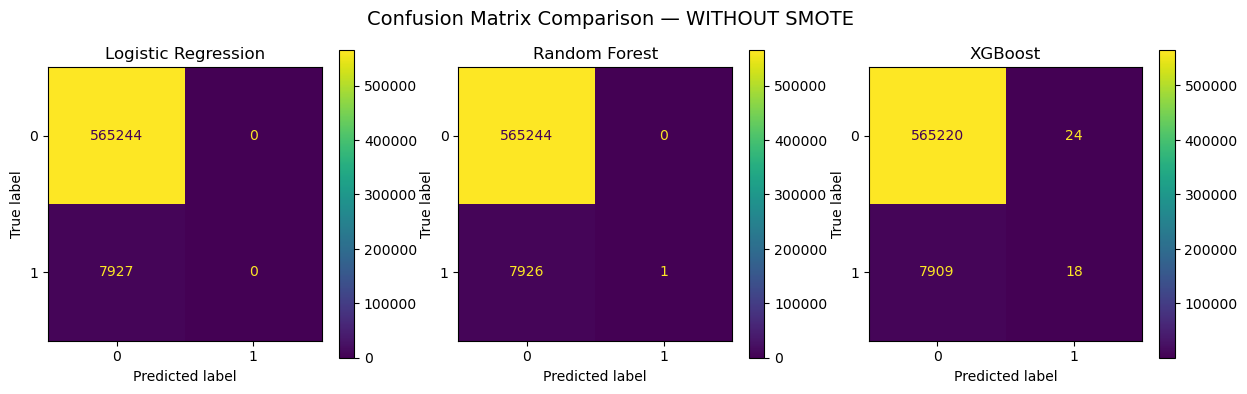

In [91]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15,4))

models_list = [
    ("Logistic Regression", log_model, y_pred_log),
    ("Random Forest", rf_model, y_pred_rf),
    ("XGBoost", xgb_model, y_pred_xgb)
]

for ax, (name, model, y_pred) in zip(axes, models_list):
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=ax)
    ax.set_title(name)

plt.suptitle("Confusion Matrix Comparison — WITHOUT SMOTE", fontsize=14)
plt.show()

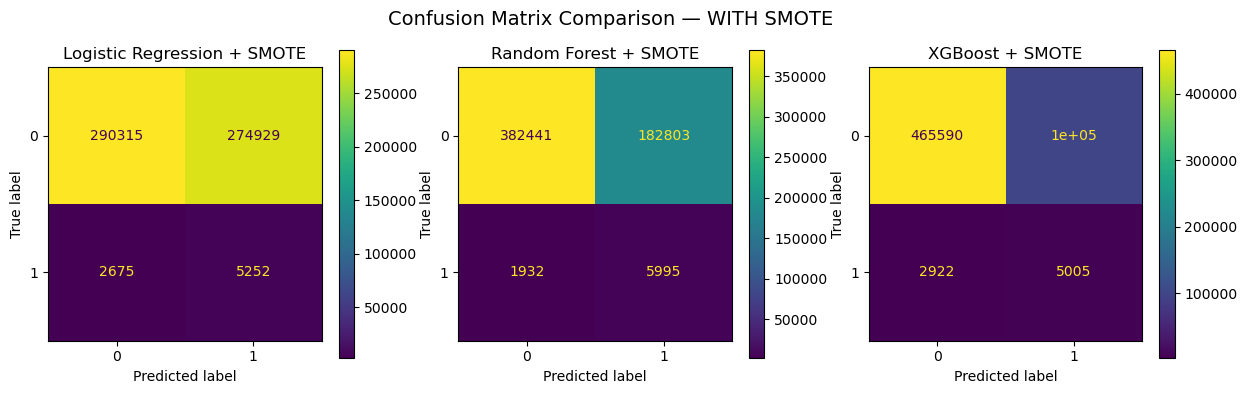

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

models_list_sm = [
    ("Logistic Regression + SMOTE", log_model_sm, y_pred_log_sm),
    ("Random Forest + SMOTE", rf_model_sm, y_pred_rf_sm),
    ("XGBoost + SMOTE", xgb_model_sm, y_pred_xgb_sm)
]

for ax, (name, model, y_pred) in zip(axes, models_list_sm):
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=ax)
    ax.set_title(name)

plt.suptitle("Confusion Matrix Comparison — WITH SMOTE", fontsize=14)
plt.show()

**OVERFITTING AND UNDERFITIING CHECK**

In [94]:
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = model.score(X_train, y_train)
    test_acc  = model.score(X_test, y_test)
    
    print(f"\n{name}")
    print(f"Train acc: {train_acc:.4f} | Test acc: {test_acc:.4f}")
    
    if train_acc > test_acc + 0.1:
        print("⚠ Possible OVERFITTING")
    elif test_acc > train_acc:
        print("⚠ Possible UNDERFITTING")
    else:
        print("✅ Good Generalization")


Logistic Regression
Train acc: 0.9862 | Test acc: 0.9862
⚠ Possible UNDERFITTING

Random Forest
Train acc: 0.9862 | Test acc: 0.9862
✅ Good Generalization

XGBoost
Train acc: 0.9862 | Test acc: 0.9862
✅ Good Generalization


In [96]:
models_smote = {
    "Logistic Regression + SMOTE": log_model_sm,
    "Random Forest + SMOTE": rf_model_sm,
    "XGBoost + SMOTE": xgb_model_sm
}

for name, model in models_smote.items():
    model.fit(X_train_s, y_train_s)
    train_acc = model.score(X_train_s, y_train_s)
    test_acc  = model.score(X_test, y_test)
    
    print(f"\n{name}")
    print(f"Train acc: {train_acc:.4f} | Test acc: {test_acc:.4f}")
    
    if train_acc > test_acc + 0.1:
        print("⚠ Possible OVERFITTING")
    elif test_acc > train_acc:
        print("⚠ Possible UNDERFITTING")
    else:
        print("✅ Good Generalization")


Logistic Regression + SMOTE
Train acc: 0.5896 | Test acc: 0.5157
✅ Good Generalization

Random Forest + SMOTE
Train acc: 0.7512 | Test acc: 0.6777
✅ Good Generalization

XGBoost + SMOTE
Train acc: 0.8024 | Test acc: 0.8210
⚠ Possible UNDERFITTING
